# 16 — Clustering de perfiles monetario-fiscales (H1)

Agrupamos a los países según su perfil monetario-fiscal (componentes PCA de la dimensión MONETARIA, cuaderno 15), probando tres algoritmos de clustering (K-Means, Jerárquico, Gaussian Mixture). 

## 1. Importaciones y carga de datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage
from scipy.stats import kruskal

import plotly.express as px
import plotly.figure_factory as ff

pd.set_option("display.max_columns", None)

In [2]:
IN_PATH_PCA = Path("data/processed/15_pca_scores.xlsx")
IN_PATH_TARGET = Path("data/processed/14_pais_features.xlsx")

df_pca_scores = pd.read_excel(IN_PATH_PCA, sheet_name="pca_scores", index_col=0)
df_target_features = pd.read_excel(IN_PATH_TARGET, sheet_name="target_inflacion")
df_regiones = pd.read_excel("df_regiones_miembros_onu.xlsx")

print(f"Shape df_pca_scores: {df_pca_scores.shape}")
print(f"Shape df_target_features: {df_target_features.shape}")
df_pca_scores.head()

Shape df_pca_scores: (184, 173)
Shape df_target_features: (193, 5)


,MONETARIA_media_PC1,MONETARIA_media_PC2,MONETARIA_media_PC3,MONETARIA_media_PC4,MONETARIA_media_PC5,MONETARIA_media_PC6,MONETARIA_media_PC7,MONETARIA_media_PC8,MONETARIA_media_PC9,MONETARIA_media_PC10,MONETARIA_media_PC11,MONETARIA_tendencia_PC1,MONETARIA_tendencia_PC2,MONETARIA_tendencia_PC3,MONETARIA_tendencia_PC4,MONETARIA_tendencia_PC5,MONETARIA_tendencia_PC6,MONETARIA_tendencia_PC7,MONETARIA_tendencia_PC8,MONETARIA_tendencia_PC9,MONETARIA_tendencia_PC10,MONETARIA_tendencia_PC11,MONETARIA_tendencia_PC12,MONETARIA_tendencia_PC13,MONETARIA_volatilidad_PC1,MONETARIA_volatilidad_PC2,MONETARIA_volatilidad_PC3,MONETARIA_volatilidad_PC4,MONETARIA_volatilidad_PC5,MONETARIA_volatilidad_PC6,MONETARIA_volatilidad_PC7,MONETARIA_volatilidad_PC8,MONETARIA_volatilidad_PC9,MONETARIA_volatilidad_PC10,MONETARIA_volatilidad_PC11,MONETARIA_volatilidad_PC12,INSTITUCIONAL_media_PC1,INSTITUCIONAL_media_PC2,INSTITUCIONAL_media_PC3,INSTITUCIONAL_media_PC4,INSTITUCIONAL_media_PC5,INSTITUCIONAL_tendencia_PC1,INSTITUCIONAL_tendencia_PC2,INSTITUCIONAL_tendencia_PC3,INSTITUCIONAL_tendencia_PC4,INSTITUCIONAL_tendencia_PC5,INSTITUCIONAL_tendencia_PC6,INSTITUCIONAL_tendencia_PC7,INSTITUCIONAL_tendencia_PC8,INSTITUCIONAL_tendencia_PC9,INSTITUCIONAL_tendencia_PC10,INSTITUCIONAL_tendencia_PC11,INSTITUCIONAL_tendencia_PC12,INSTITUCIONAL_tendencia_PC13,INSTITUCIONAL_volatilidad_PC1,INSTITUCIONAL_volatilidad_PC2,INSTITUCIONAL_volatilidad_PC3,INSTITUCIONAL_volatilidad_PC4,INSTITUCIONAL_volatilidad_PC5,INSTITUCIONAL_volatilidad_PC6,INSTITUCIONAL_volatilidad_PC7,INSTITUCIONAL_volatilidad_PC8,INSTITUCIONAL_volatilidad_PC9,INSTITUCIONAL_volatilidad_PC10,INSTITUCIONAL_volatilidad_PC11,INSTITUCIONAL_volatilidad_PC12,INSTITUCIONAL_volatilidad_PC13,INSTITUCIONAL_volatilidad_PC14,ESTRUCTURAL_media_PC1,ESTRUCTURAL_media_PC2,ESTRUCTURAL_media_PC3,ESTRUCTURAL_media_PC4,ESTRUCTURAL_media_PC5,ESTRUCTURAL_media_PC6,ESTRUCTURAL_media_PC7,ESTRUCTURAL_media_PC8,ESTRUCTURAL_media_PC9,ESTRUCTURAL_media_PC10,ESTRUCTURAL_media_PC11,ESTRUCTURAL_media_PC12,ESTRUCTURAL_media_PC13,ESTRUCTURAL_media_PC14,ESTRUCTURAL_media_PC15,ESTRUCTURAL_media_PC16,ESTRUCTURAL_tendencia_PC1,ESTRUCTURAL_tendencia_PC2,ESTRUCTURAL_tendencia_PC3,ESTRUCTURAL_tendencia_PC4,ESTRUCTURAL_tendencia_PC5,ESTRUCTURAL_tendencia_PC6,ESTRUCTURAL_tendencia_PC7,ESTRUCTURAL_tendencia_PC8,ESTRUCTURAL_tendencia_PC9,ESTRUCTURAL_tendencia_PC10,ESTRUCTURAL_tendencia_PC11,ESTRUCTURAL_tendencia_PC12,ESTRUCTURAL_tendencia_PC13,ESTRUCTURAL_tendencia_PC14,ESTRUCTURAL_tendencia_PC15,ESTRUCTURAL_tendencia_PC16,ESTRUCTURAL_tendencia_PC17,ESTRUCTURAL_tendencia_PC18,ESTRUCTURAL_tendencia_PC19,ESTRUCTURAL_volatilidad_PC1,ESTRUCTURAL_volatilidad_PC2,ESTRUCTURAL_volatilidad_PC3,ESTRUCTURAL_volatilidad_PC4,ESTRUCTURAL_volatilidad_PC5,ESTRUCTURAL_volatilidad_PC6,ESTRUCTURAL_volatilidad_PC7,ESTRUCTURAL_volatilidad_PC8,ESTRUCTURAL_volatilidad_PC9,ESTRUCTURAL_volatilidad_PC10,ESTRUCTURAL_volatilidad_PC11,ESTRUCTURAL_volatilidad_PC12,ESTRUCTURAL_volatilidad_PC13,ESTRUCTURAL_volatilidad_PC14,ESTRUCTURAL_volatilidad_PC15,ESTRUCTURAL_volatilidad_PC16,ESTRUCTURAL_volatilidad_PC17,ESTRUCTURAL_volatilidad_PC18,ESTRUCTURAL_volatilidad_PC19,SOCIODEMOGRAFICA_media_PC1,SOCIODEMOGRAFICA_media_PC2,SOCIODEMOGRAFICA_media_PC3,SOCIODEMOGRAFICA_media_PC4,SOCIODEMOGRAFICA_media_PC5,SOCIODEMOGRAFICA_media_PC6,SOCIODEMOGRAFICA_media_PC7,SOCIODEMOGRAFICA_media_PC8,SOCIODEMOGRAFICA_media_PC9,SOCIODEMOGRAFICA_media_PC10,SOCIODEMOGRAFICA_tendencia_PC1,SOCIODEMOGRAFICA_tendencia_PC2,SOCIODEMOGRAFICA_tendencia_PC3,SOCIODEMOGRAFICA_tendencia_PC4,SOCIODEMOGRAFICA_tendencia_PC5,SOCIODEMOGRAFICA_tendencia_PC6,SOCIODEMOGRAFICA_tendencia_PC7,SOCIODEMOGRAFICA_tendencia_PC8,SOCIODEMOGRAFICA_tendencia_PC9,SOCIODEMOGRAFICA_tendencia_PC10,SOCIODEMOGRAFICA_tendencia_PC11,SOCIODEMOGRAFICA_tendencia_PC12,SOCIODEMOGRAFICA_tendencia_PC13,SOCIODEMOGRAFICA_tendencia_PC14,SOCIODEMOGRAFICA_tendencia_PC15,SOCIODEMOGRAFICA_tendencia_PC16,SOCIODEMOGRAFICA_tendencia_PC17,SOCIODEMOGRAFICA_tende

## 2. Selección de variables monetarias

**Objetivo:** quedarnos solo con los componentes PCA de la dimensión MONETARIA (media, tendencia, volatilidad), excluyendo institucional, estructural y sociodemográfica.

**Justificación metodológica:** H1 se comprueba agrupando países por perfil monetario-fiscal exclusivamente

**Resultado esperado:** matriz `X_completo` de 184 países × 32 componentes (9 de media + 12 de tendencia + 11 de volatilidad).

In [3]:
cols_monetaria = [c for c in df_pca_scores.columns if c.startswith("MONETARIA_")]
X_completo = df_pca_scores[cols_monetaria].copy()

print(f"N columnas MONETARIA: {len(cols_monetaria)}")
print(f"Shape X_completo: {X_completo.shape}")
X_completo.describe().T[["mean", "std", "min", "max"]].head()

N columnas MONETARIA: 36
Shape X_completo: (184, 36)


,mean,std,min,max
MONETARIA_media_PC1,1.351576e-16,3.210493,-8.048805,8.517660
MONETARIA_media_PC2,-7.723291e-17,2.459671,-5.314049,7.148977
MONETARIA_media_PC3,3.861645e-17,2.290545,-5.398117,20.147902
MONETARIA_media_PC4,-5.792468e-17,1.843236,-4.260746,8.872264
MONETARIA_media_PC5,-1.689470e-16,1.715325,-8.294306,13.291763


## 2.1 Identificación y exclusión de perfiles monetarios extremos

**Objetivo:** identificar países cuyo perfil monetario-fiscal es un caso atípico multivariado dentro de esta dimensión, y excluirlos del clustering de perfiles.

**Justificación metodológica:** con las 32 componentes juntas, un puñado de países muy alejados del resto domina la distancia euclídea y hace que cualquier algoritmo los aísle en vez de encontrar estructura en el resto. Usamos el mismo criterio ya aplicado en el cuaderno 15 para excluir países por missingness (regla de Tukey: Q3 + 1.5×RIC), pero aplicado ahora a la distancia de cada país al centroide del conjunto en el espacio de las 32 componentes monetarias, no a disponibilidad de datos.

**Resultado esperado:** `df_distancias_monetaria` con la distancia de cada país al centroide; lista de países atípicos identificados; `X` como la matriz ya sin esos países.

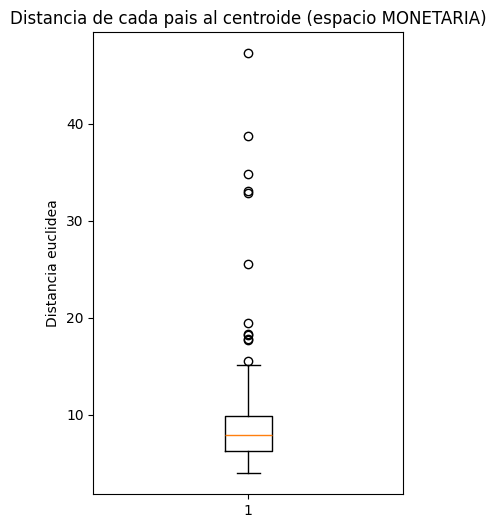

,ISO-alpha3,distancia_centroide,orden,Member State
169,GNQ,14.563348,170,Equatorial Guinea
170,VNM,14.914904,171,Viet Nam
171,SOM,15.109606,172,Somalia
172,VEN,15.508126,173,Venezuela (Bolivarian Republic of)
173,KIR,17.666848,174,Kiribati
174,YEM,17.815603,175,Yemen
175,UZB,18.212562,176,Uzbekistan
176,ISL,18.305956,177,Iceland
177,SSD,19.429443,178,South Sudan
178,LBY,25.574955,179,Libya


In [4]:
centroide = X_completo.mean(axis=0)
distancia_centroide = np.linalg.norm(X_completo - centroide, axis=1)

df_distancias_monetaria = pd.DataFrame({
    "ISO-alpha3": X_completo.index,
    "distancia_centroide": distancia_centroide,
}).sort_values("distancia_centroide").reset_index(drop=True)
df_distancias_monetaria["orden"] = range(1, len(df_distancias_monetaria) + 1)

df_distancias_monetaria = df_distancias_monetaria.merge(
    df_regiones[["ISO-alpha3", "Member State"]], on="ISO-alpha3", how="left"
)

fig, ax = plt.subplots(figsize=(4, 6))
ax.boxplot(df_distancias_monetaria["distancia_centroide"], vert=True)
ax.set_title("Distancia de cada pais al centroide (espacio MONETARIA)")
ax.set_ylabel("Distancia euclidea")
plt.show()

df_distancias_monetaria.tail(15)

In [5]:
Q1 = df_distancias_monetaria["distancia_centroide"].quantile(0.25)
Q3 = df_distancias_monetaria["distancia_centroide"].quantile(0.75)
IQR = Q3 - Q1
umbral_tukey_monetaria = Q3 + 1.5 * IQR

print(f"Q1: {Q1:.2f}  |  Q3: {Q3:.2f}  |  RIC: {IQR:.2f}")
print(f"Umbral de outlier (Tukey, Q3 + 1.5*RIC): {umbral_tukey_monetaria:.2f}")

paises_outlier_monetaria = df_distancias_monetaria.loc[
    df_distancias_monetaria["distancia_centroide"] > umbral_tukey_monetaria, "ISO-alpha3"
].tolist()

print(f"\nPaises identificados como outlier monetario ({len(paises_outlier_monetaria)}):")
print(df_distancias_monetaria.loc[
    df_distancias_monetaria["ISO-alpha3"].isin(paises_outlier_monetaria),
    ["ISO-alpha3", "Member State", "distancia_centroide"]
])

Q1: 6.29  |  Q3: 9.86  |  RIC: 3.57
Umbral de outlier (Tukey, Q3 + 1.5*RIC): 15.21

Paises identificados como outlier monetario (12):
    ISO-alpha3                        Member State  distancia_centroide
172        VEN  Venezuela (Bolivarian Republic of)            15.508126
173        KIR                            Kiribati            17.666848
174        YEM                               Yemen            17.815603
175        UZB                          Uzbekistan            18.212562
176        ISL                             Iceland            18.305956
177        SSD                         South Sudan            19.429443
178        LBY                               Libya            25.574955
179        SDN                               Sudan            32.830335
180        IRN          Iran (Islamic Republic of)            33.014098
181        ZWE                            Zimbabwe            34.773602
182        SLE                        Sierra Leone            38.749684
18

In [6]:
X = X_completo.drop(index=paises_outlier_monetaria)
N_PAISES, N_FEATURES = X.shape

print(f"Shape X_completo: {X_completo.shape}")
print(f"Shape X (sin outliers monetarios): {X.shape}")

Shape X_completo: (184, 36)
Shape X (sin outliers monetarios): (172, 36)


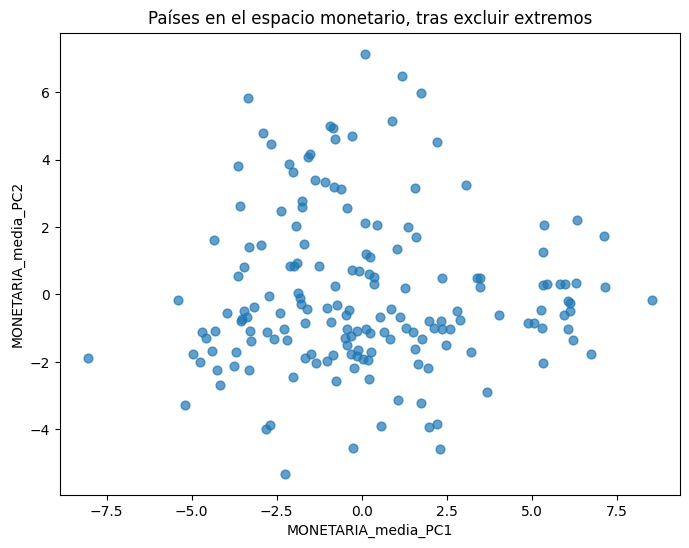

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X["MONETARIA_media_PC1"], X["MONETARIA_media_PC2"], s=40, alpha=0.7)
ax.set_xlabel("MONETARIA_media_PC1")
ax.set_ylabel("MONETARIA_media_PC2")
ax.set_title("Países en el espacio monetario, tras excluir extremos")
plt.show()

## 3. K-Means

### 3.1 Chequeo de estabilidad de `n_init`

**Objetivo:** determinar a partir de qué valor de `n_init` el resultado de K-Means deja de cambiar entre corridas, para justificar con evidencia el valor usado en el grid de k (en vez de fijarlo por criterio).

**Justificación metodológica:** K-Means converge a óptimos locales según la inicialización de los centroides. Un `n_init` más alto nunca empeora el resultado (sklearn se queda con la mejor corrida por inercia), pero cuesta más cómputo — buscamos el punto en que aumentar `n_init` ya no reduce la variabilidad entre corridas repetidas con distinta semilla, sobre un k representativo del grid.

**Resultado esperado:** `df_estabilidad_kmeans` con la dispersión (SD relativa) de la inercia final entre repeticiones, para cada `n_init` candidato; `N_INIT_ELEGIDO_KMEANS` fijado en el primero que cae debajo de la tolerancia.

In [8]:
K_REPRESENTATIVO = 5
N_INIT_CANDIDATOS = [1, 5, 10, 25, 50]
N_REPETICIONES = 8
SEMILLA_BASE = 42
TOLERANCIA_SD_RELATIVA = 0.001

resultados_estabilidad_kmeans = []
for n_init_candidato in N_INIT_CANDIDATOS:
    inercias = []
    for rep in range(N_REPETICIONES):
        modelo = KMeans(n_clusters=K_REPRESENTATIVO, n_init=n_init_candidato, random_state=SEMILLA_BASE + rep)
        modelo.fit(X)
        inercias.append(modelo.inertia_)
    inercias = np.array(inercias)
    sd_relativa = inercias.std() / inercias.mean()
    resultados_estabilidad_kmeans.append({
        "n_init": n_init_candidato,
        "inercia_media": inercias.mean(),
        "sd_inercia": inercias.std(),
        "sd_relativa": sd_relativa,
    })

df_estabilidad_kmeans = pd.DataFrame(resultados_estabilidad_kmeans)

candidatos_estables = df_estabilidad_kmeans[df_estabilidad_kmeans["sd_relativa"] < TOLERANCIA_SD_RELATIVA]
if len(candidatos_estables) > 0:
    N_INIT_ELEGIDO_KMEANS = int(candidatos_estables.iloc[0]["n_init"])
else:
    N_INIT_ELEGIDO_KMEANS = int(df_estabilidad_kmeans.iloc[-1]["n_init"])
    print("Ningun n_init probado baja de la tolerancia — se usa el mayor candidato y se documenta como limite del grid probado.")

print(f"N_INIT_ELEGIDO_KMEANS = {N_INIT_ELEGIDO_KMEANS}")
df_estabilidad_kmeans

N_INIT_ELEGIDO_KMEANS = 25


,n_init,inercia_media,sd_inercia,sd_relativa
0,1,8288.059865,257.412959,0.031058
1,5,8043.175320,28.128422,0.003497
2,10,8020.325623,12.420186,0.001549
3,25,8011.304731,5.765632,0.000720
4,50,8006.699910,3.422654,0.000427


### 3.2 Grid de k (con `n_init` ya fijado)

In [9]:
K_GRID = range(3, 9)  # arranca en 3, mismo criterio que Jerarquico: k=2 no alcanza como perfil

resultados_kmeans = []
labels_kmeans_por_k = {}

for k in K_GRID:
    modelo = KMeans(n_clusters=k, n_init=N_INIT_ELEGIDO_KMEANS, random_state=SEMILLA_BASE)
    labels = modelo.fit_predict(X)
    labels_kmeans_por_k[k] = labels

    tamanios = pd.Series(labels).value_counts()
    resultados_kmeans.append({
        "algoritmo": "KMeans",
        "parametro": "-",
        "k": k,
        "silhouette": silhouette_score(X, labels),
        "davies_bouldin": davies_bouldin_score(X, labels),
        "calinski_harabasz": calinski_harabasz_score(X, labels),
        "inercia": modelo.inertia_,
        "tamanio_min": tamanios.min(),
        "tamanio_max": tamanios.max(),
    })

df_resultados_kmeans = pd.DataFrame(resultados_kmeans)
df_resultados_kmeans

,algoritmo,parametro,k,silhouette,davies_bouldin,calinski_harabasz,inercia,tamanio_min,tamanio_max
0,KMeans,-,3,0.162570,2.053247,27.204676,9174.561310,26,101
1,KMeans,-,4,0.124915,2.294934,23.525771,8540.436889,23,67
2,KMeans,-,5,0.132874,2.083195,21.465760,8009.973295,12,59
3,KMeans,-,6,0.142127,1.938150,19.766356,7602.176360,9,56
4,KMeans,-,7,0.114782,1.935421,18.088317,7316.090792,11,46
5,KMeans,-,8,0.121605,1.947127,16.912377,7043.680578,8,43


In [10]:
fig_codo = px.line(
    df_resultados_kmeans, x="k", y="inercia", markers=True,
    title="K-Means: inercia por k (metodo del codo)"
)
fig_codo.show()

### 3.3 Inspección visual de las particiones

Antes de elegir k con las métricas, miramos país por país cómo queda armado cada grupo, para varios k, y un gráfico simple para verlo.

In [11]:
K_INSPECCIONAR = [3, 4, 5, 6]

for k in K_INSPECCIONAR:
    labels = labels_kmeans_por_k[k]
    df_tmp = pd.DataFrame({"ISO-alpha3": X.index, "cluster": labels}).merge(
        df_regiones[["ISO-alpha3", "Member State"]], on="ISO-alpha3", how="left"
    )
    print(f"===== K-Means, k={k} =====")
    for c in sorted(df_tmp["cluster"].unique()):
        paises_c = df_tmp.loc[df_tmp["cluster"] == c, "Member State"].tolist()
        print(f"Grupo {c} (n={len(paises_c)}): {paises_c}")
    print()

===== K-Means, k=3 =====
Grupo 0 (n=45): ['Australia', 'Austria', 'Belgium', 'Bulgaria', 'Belarus', 'Canada', 'Switzerland', 'Chile', 'Cyprus', 'Czechia', 'Germany', 'Denmark', 'Spain', 'Estonia', 'Finland', 'France', 'United Kingdom', 'Greece', 'Croatia', 'Hungary', 'Ireland', 'Israel', 'Italy', 'Japan', 'Republic of Korea', 'Lithuania', 'Luxembourg', 'Latvia', 'Malta', 'Montenegro', 'Netherlands (Kingdom of the)', 'Norway', 'New Zealand', 'Palau', 'Poland', 'Portugal', 'Romania', 'Serbia', 'Slovakia', 'Slovenia', 'Sweden', 'T��rkiye', 'Ukraine', 'United States', 'South Africa']
Grupo 1 (n=26): ['Angola', 'United Arab Emirates', 'Azerbaijan', 'Bahrain', 'Brunei Darussalam', 'Bhutan', 'Botswana', 'China', 'Congo', 'Algeria', 'Gabon', 'Equatorial Guinea', 'Iraq', 'Kazakhstan', 'Kuwait', 'Myanmar', 'Mongolia', 'Oman', 'Papua New Guinea', 'Qatar', 'Russian Federation', 'Saudi Arabia', 'Singapore', 'Suriname', 'Tajikistan', 'Turkmenistan']
Grupo 2 (n=101): ['Afghanistan', 'Albania', 'Argen

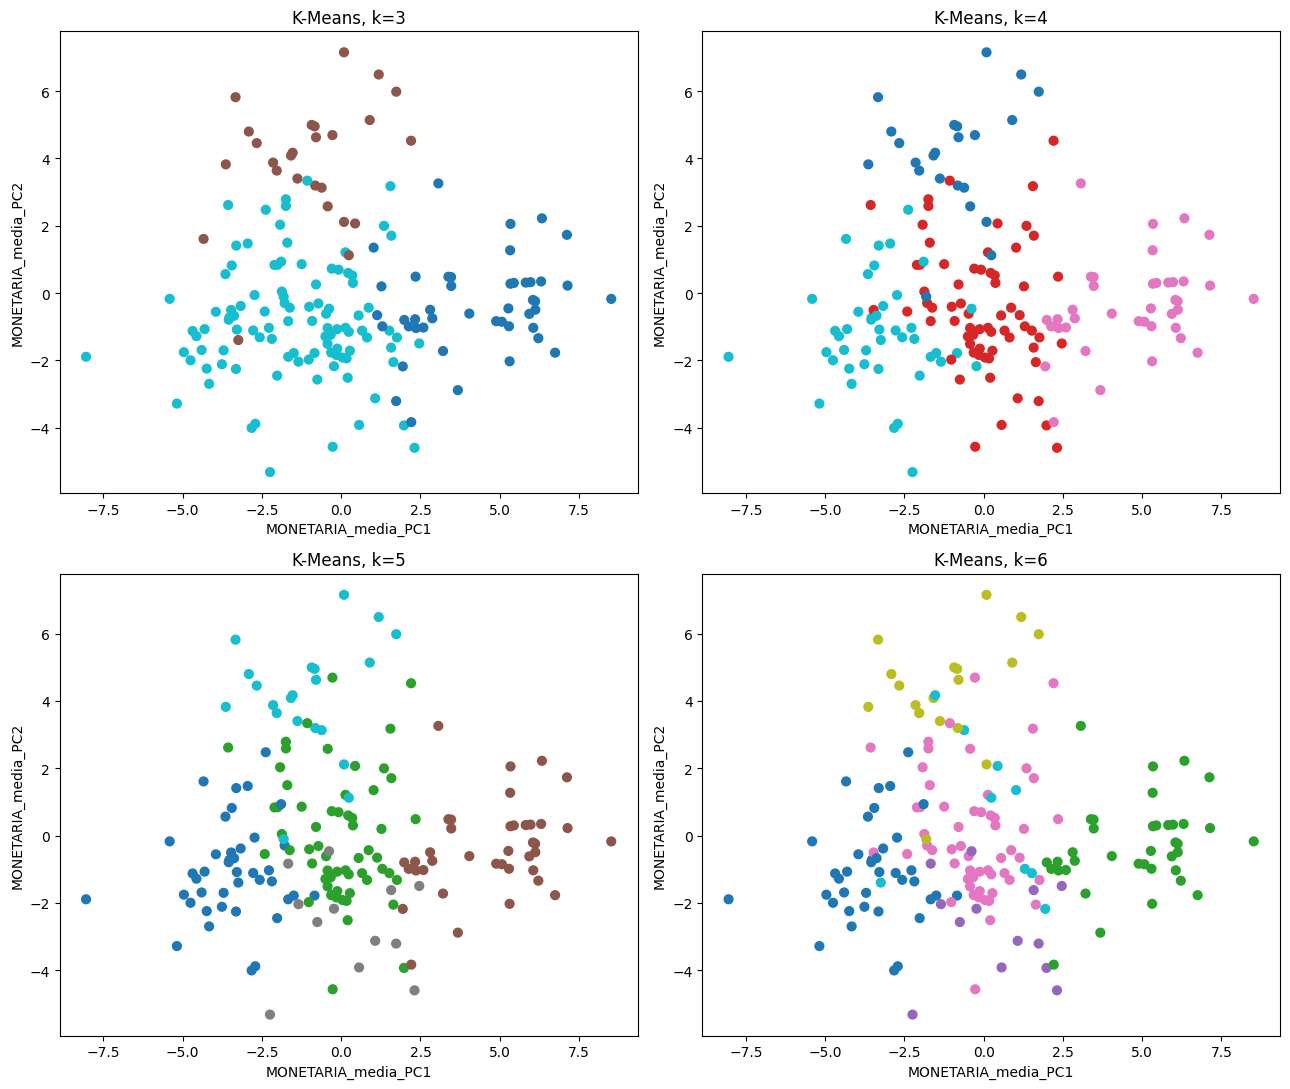

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
for ax, k in zip(axes.flat, K_INSPECCIONAR):
    labels = labels_kmeans_por_k[k]
    ax.scatter(X["MONETARIA_media_PC1"], X["MONETARIA_media_PC2"], c=labels, cmap="tab10", s=40)
    ax.set_title(f"K-Means, k={k}")
    ax.set_xlabel("MONETARIA_media_PC1")
    ax.set_ylabel("MONETARIA_media_PC2")
plt.tight_layout()
plt.show()

## 4. Jerárquico



In [13]:
LINKAGES_GRID = ["ward", "average", "complete"]
K_GRID_JERARQUICO = range(3, 9)  # arranca en 3, k=2 no alcanza como perfil

resultados_ward = []
labels_ward_por_config = {}

for enlace in LINKAGES_GRID:
    for k in K_GRID_JERARQUICO:
        modelo = AgglomerativeClustering(n_clusters=k, linkage=enlace)
        labels = modelo.fit_predict(X)
        labels_ward_por_config[(enlace, k)] = labels

        tamanios = pd.Series(labels).value_counts()
        resultados_ward.append({
            "algoritmo": "Jerarquico",
            "parametro": enlace,
            "k": k,
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "inercia": np.nan,
            "tamanio_min": tamanios.min(),
            "tamanio_max": tamanios.max(),
        })

df_resultados_ward = pd.DataFrame(resultados_ward)
df_resultados_ward.sort_values("silhouette", ascending=False).head(25)

,algoritmo,parametro,k,silhouette,davies_bouldin,calinski_harabasz,inercia,tamanio_min,tamanio_max
6,Jerarquico,average,3,0.273587,0.934750,5.048315,NaN,1,168
7,Jerarquico,average,4,0.253362,0.836799,4.383527,NaN,1,167
8,Jerarquico,average,5,0.213741,0.849043,4.724423,NaN,1,165
9,Jerarquico,average,6,0.210494,0.947644,5.155849,NaN,1,162
12,Jerarquico,complete,3,0.201887,1.664604,9.976818,NaN,3,155
10,Jerarquico,average,7,0.197331,0.891711,4.811611,NaN,1,161
11,Jerarquico,average,8,0.188315,0.773771,4.484092,NaN,1,161
15,Jerarquico,complete,6,0.163631,1.466319,13.704124,NaN,1,112
14,Jerarquico,complete,5,0.163211,1.729444,15.973245,NaN,3,112
13,Jerarquico,complete,4,0.160067,1.752631,17.357234,NaN,3,112


Dendrograma (enlace Ward, ilustrativo — no determina por si solo la eleccion de linkage)

In [15]:
matriz_enlace = linkage(X, method="ward")
n_paises = X.shape[0]

fig_dendro = ff.create_dendrogram(
    X.values,
    labels=X.index.tolist(),
    linkagefun=lambda x: matriz_enlace,
    orientation="left",
)
fig_dendro.update_layout(
    title="Dendrograma - perfiles monetario-fiscales (Ward)",
    width=900,
    height=max(1200, n_paises * 14),
    yaxis=dict(tickfont=dict(size=9)),
)
fig_dendro.show()

## 5. Gaussian Mixture

### 5.1 Chequeo de estabilidad de `n_init`

**Objetivo:** mismo chequeo que en K-Means (sección 3.1), aplicado a GMM.


**Resultado esperado:** `df_estabilidad_gmm` con la SD relativa del BIC por `n_init` candidato; `N_INIT_ELEGIDO_GMM`.

In [16]:
resultados_estabilidad_gmm = []
for n_init_candidato in N_INIT_CANDIDATOS:
    bics = []
    for rep in range(N_REPETICIONES):
        modelo = GaussianMixture(
            n_components=K_REPRESENTATIVO, covariance_type="diag",
            n_init=n_init_candidato, random_state=SEMILLA_BASE + rep
        )
        modelo.fit(X)
        bics.append(modelo.bic(X))
    bics = np.array(bics)
    sd_relativa = bics.std() / abs(bics.mean())
    resultados_estabilidad_gmm.append({
        "n_init": n_init_candidato,
        "bic_medio": bics.mean(),
        "sd_bic": bics.std(),
        "sd_relativa": sd_relativa,
    })

df_estabilidad_gmm = pd.DataFrame(resultados_estabilidad_gmm)

candidatos_estables_gmm = df_estabilidad_gmm[df_estabilidad_gmm["sd_relativa"] < TOLERANCIA_SD_RELATIVA]
if len(candidatos_estables_gmm) > 0:
    N_INIT_ELEGIDO_GMM = int(candidatos_estables_gmm.iloc[0]["n_init"])
else:
    N_INIT_ELEGIDO_GMM = int(df_estabilidad_gmm.iloc[-1]["n_init"])
    print("Ningun n_init probado baja de la tolerancia — se usa el mayor candidato y se documenta como limite del grid probado.")

print(f"N_INIT_ELEGIDO_GMM = {N_INIT_ELEGIDO_GMM}")
df_estabilidad_gmm

Ningun n_init probado baja de la tolerancia — se usa el mayor candidato y se documenta como limite del grid probado.
N_INIT_ELEGIDO_GMM = 50


,n_init,bic_medio,sd_bic,sd_relativa
0,1,19963.013662,205.598663,0.010299
1,5,19638.265142,119.229427,0.006071
2,10,19597.888243,112.404441,0.005736
3,25,19487.501611,124.494357,0.006388
4,50,19352.687639,97.238385,0.005025


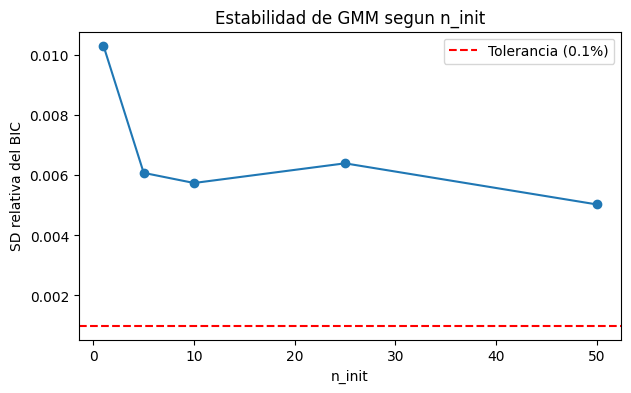

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(df_estabilidad_gmm["n_init"], df_estabilidad_gmm["sd_relativa"], marker="o")
ax.axhline(TOLERANCIA_SD_RELATIVA, color="red", linestyle="--", label="Tolerancia (0.1%)")
ax.set_xlabel("n_init")
ax.set_ylabel("SD relativa del BIC")
ax.set_title("Estabilidad de GMM segun n_init")
ax.legend()
plt.show()

### 5.2 Exclusión cuantitativa de `covariance_type='full'`

**Objetivo:** decidir con evidencia, no solo intuición, si `full` es viable dentro del grid de k que vamos a correr.

**Justificación metodológica:** una covarianza completa en 32 dimensiones tiene 32×33/2 = 528 parámetros por clúster — estimarla de forma confiable requiere que cada clúster tenga bastantes más de 32 países. Comparamos el tamaño de clúster promedio (N/k) contra las 32 dimensiones para cada k del grid.

**Resultado esperado:** tabla que muestra a partir de qué k el tamaño de clúster promedio ya es menor a la dimensionalidad — justifica excluir `full` de todo el grid (no solo de los k altos), para mantener comparabilidad entre los k probados.

In [18]:
df_chequeo_full = pd.DataFrame({
    "k": list(K_GRID),
    "tamanio_promedio_cluster": [round(N_PAISES / k, 1) for k in K_GRID],
    "n_features": N_FEATURES,
})
df_chequeo_full["tamanio_promedio_menor_a_features"] = df_chequeo_full["tamanio_promedio_cluster"] < df_chequeo_full["n_features"]
df_chequeo_full

,k,tamanio_promedio_cluster,n_features,tamanio_promedio_menor_a_features
0,3,57.3,36,False
1,4,43.0,36,False
2,5,34.4,36,True
3,6,28.7,36,True
4,7,24.6,36,True
5,8,21.5,36,True


### 5.3 Grid de `covariance_type` × k

In [19]:
COVARIANCE_GRID = ["diag", "tied", "spherical"]

resultados_gmm = []
labels_gmm_por_config = {}

for cov_type in COVARIANCE_GRID:
    for k in K_GRID:
        modelo = GaussianMixture(
            n_components=k, covariance_type=cov_type,
            n_init=N_INIT_ELEGIDO_GMM, random_state=SEMILLA_BASE
        )
        modelo.fit(X)
        labels = modelo.predict(X)
        labels_gmm_por_config[(cov_type, k)] = labels

        tamanios = pd.Series(labels).value_counts()
        resultados_gmm.append({
            "algoritmo": "GMM",
            "parametro": cov_type,
            "k": k,
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
            "bic": modelo.bic(X),
            "tamanio_min": tamanios.min(),
            "tamanio_max": tamanios.max(),
        })

df_resultados_gmm = pd.DataFrame(resultados_gmm)
df_resultados_gmm.sort_values("silhouette", ascending=False).head(10)

,algoritmo,parametro,k,silhouette,davies_bouldin,calinski_harabasz,bic,tamanio_min,tamanio_max
7,GMM,tied,4,0.167378,1.830710,21.112526,18802.252406,11,105
6,GMM,tied,3,0.157526,1.366704,18.363573,18595.287906,1,125
9,GMM,tied,6,0.147506,2.014959,15.418269,18831.458978,2,79
8,GMM,tied,5,0.134905,1.947264,17.757790,18703.037484,1,79
10,GMM,tied,7,0.122916,1.791493,16.374752,18774.115015,1,60
4,GMM,diag,7,0.118429,2.080803,13.944336,19624.047582,1,56
12,GMM,spherical,3,0.109601,3.098066,20.254123,20206.496728,34,74
3,GMM,diag,6,0.103673,2.145189,14.551164,19456.767827,1,53
11,GMM,tied,8,0.099203,1.761614,15.077589,18876.778423,1,63
5,GMM,diag,8,0.096020,2.100832,13.610160,19647.385733,1,55


In [20]:
fig_bic = px.line(
    df_resultados_gmm, x="k", y="bic", color="parametro", markers=True,
    title="GMM: BIC por k y covariance_type (menor es mejor)"
)
fig_bic.show()

## 6. Comparación de métricas entre algoritmos

In [21]:
df_comparacion = pd.concat([
    df_resultados_kmeans.drop(columns=["inercia"]),
    df_resultados_ward.drop(columns=["inercia"]),
    df_resultados_gmm.drop(columns=["bic"]),
], ignore_index=True)

df_comparacion["config"] = df_comparacion["algoritmo"] + " (" + df_comparacion["parametro"] + ")"
df_comparacion.sort_values("silhouette", ascending=False).head(15)

,algoritmo,parametro,k,silhouette,davies_bouldin,calinski_harabasz,tamanio_min,tamanio_max,config
12,Jerarquico,average,3,0.273587,0.934750,5.048315,1,168,Jerarquico (average)
13,Jerarquico,average,4,0.253362,0.836799,4.383527,1,167,Jerarquico (average)
14,Jerarquico,average,5,0.213741,0.849043,4.724423,1,165,Jerarquico (average)
15,Jerarquico,average,6,0.210494,0.947644,5.155849,1,162,Jerarquico (average)
18,Jerarquico,complete,3,0.201887,1.664604,9.976818,3,155,Jerarquico (complete)
16,Jerarquico,average,7,0.197331,0.891711,4.811611,1,161,Jerarquico (average)
17,Jerarquico,average,8,0.188315,0.773771,4.484092,1,161,Jerarquico (average)
31,GMM,tied,4,0.167378,1.830710,21.112526,11,105,GMM (tied)
21,Jerarquico,complete,6,0.163631,1.466319,13.704124,1,112,Jerarquico (complete)
20,Jerarquico,complete,5,0.163211,1.729444,15.973245,3,112,Jerarquico (complete)


In [22]:
fig_metricas = px.line(
    df_comparacion, x="k", y="silhouette", color="config", markers=True,
    title="Silhouette Score por configuracion y k"
)
fig_metricas.show()

fig_db = px.line(
    df_comparacion, x="k", y="davies_bouldin", color="config", markers=True,
    title="Davies-Bouldin por configuracion y k (menor es mejor)"
)
fig_db.show()

## 7. Selección de algoritmo y configuración final

**Objetivo:** elegir una única combinación (algoritmo, parámetro, k) para usar en el resto del análisis.

**Justificación metodológica:** no elegimos automáticamente el máximo de una sola métrica — filtramos primero las configuraciones con grupos demasiado chicos para que el cruce posterior con inflación tenga sentido (`tamanio_min` por debajo del umbral queda descartado), y dentro de las que quedan, comparamos las tres métricas y los tamaños de grupo.

**Resultado esperado:** tabla de candidatas viables ordenada por silhouette; `ALGORITMO_FINAL`, `PARAMETRO_FINAL` y `K_FINAL` se fijan manualmente después de revisarla.

In [23]:
def tamanios_por_cluster(algoritmo, parametro, k):
    if algoritmo == "KMeans":
        labels = labels_kmeans_por_k[k]
    elif algoritmo == "Jerarquico":
        labels = labels_ward_por_config[(parametro, k)]
    elif algoritmo == "GMM":
        labels = labels_gmm_por_config[(parametro, k)]
    return pd.Series(labels).value_counts().sort_index().to_dict()

df_comparacion["tamanios"] = df_comparacion.apply(
    lambda fila: tamanios_por_cluster(fila["algoritmo"], fila["parametro"], fila["k"]), axis=1
)

In [24]:
TAMANIO_MINIMO_ACEPTABLE = 5

df_candidatas = df_comparacion[df_comparacion["tamanio_min"] >= TAMANIO_MINIMO_ACEPTABLE].copy()
df_candidatas = df_candidatas.sort_values("silhouette", ascending=False)
df_candidatas

,algoritmo,parametro,k,silhouette,davies_bouldin,calinski_harabasz,tamanio_min,tamanio_max,config,tamanios
31,GMM,tied,4,0.167378,1.830710,21.112526,11,105,GMM (tied),"{0: 11, 1: 40, 2: 105, 3: 16}"
0,KMeans,-,3,0.162570,2.053247,27.204676,26,101,KMeans (-),"{0: 45, 1: 26, 2: 101}"
7,Jerarquico,ward,4,0.159889,2.214037,21.219770,14,94,Jerarquico (ward),"{0: 94, 1: 40, 2: 24, 3: 14}"
6,Jerarquico,ward,3,0.148886,2.506080,24.627266,38,94,Jerarquico (ward),"{0: 38, 1: 40, 2: 94}"
3,KMeans,-,6,0.142127,1.938150,19.766356,9,56,KMeans (-),"{0: 38, 1: 38, 2: 13, 3: 56, 4: 18, 5: 9}"
2,KMeans,-,5,0.132874,2.083195,21.465760,12,59,KMeans (-),"{0: 41, 1: 59, 2: 39, 3: 12, 4: 21}"
9,Jerarquico,ward,6,0.131533,2.037346,18.568044,12,54,Jerarquico (ward),"{0: 40, 1: 54, 2: 12, 3: 14, 4: 40, 5: 12}"
1,KMeans,-,4,0.124915,2.294934,23.525771,23,67,KMeans (-),"{0: 23, 1: 67, 2: 39, 3: 43}"
5,KMeans,-,8,0.121605,1.947127,16.912377,8,43,KMeans (-),"{0: 21, 1: 43, 2: 19, 3: 8, 4: 9, 5: 39, 6: 13..."
8,Jerarquico,ward,5,0.115804,2.263429,19.535538,14,54,Jerarquico (ward),"{0: 24, 1: 54, 2: 40, 3: 14, 4: 40}"


Necesito hacer esto más interpretable. asi que vamos a ver en cada caso como se configuran los grupos en cada caso

In [25]:
for _, fila in df_candidatas.iterrows():
    algoritmo, parametro, k = fila["algoritmo"], fila["parametro"], fila["k"]

    if algoritmo == "KMeans":
        labels = labels_kmeans_por_k[k]
    elif algoritmo == "Jerarquico":
        labels = labels_ward_por_config[(parametro, k)]
    elif algoritmo == "GMM":
        labels = labels_gmm_por_config[(parametro, k)]

    df_tmp = pd.DataFrame({"ISO-alpha3": X.index, "cluster": labels}).merge(
        df_regiones[["ISO-alpha3", "Member State"]], on="ISO-alpha3", how="left"
    )

    print(f"===== {algoritmo} ({parametro}), k={k} — silhouette={fila['silhouette']:.3f} =====")
    for c in sorted(df_tmp["cluster"].unique()):
        paises_c = df_tmp.loc[df_tmp["cluster"] == c, "Member State"].tolist()
        print(f"Grupo {c} (n={len(paises_c)}): {paises_c}")
    print()

===== GMM (tied), k=4 — silhouette=0.167 =====
Grupo 0 (n=11): ['Azerbaijan', 'Belarus', 'Kazakhstan', 'Republic of Moldova', 'North Macedonia', 'Mongolia', 'Russian Federation', 'Serbia', 'Tajikistan', 'Turkmenistan', 'Ukraine']
Grupo 1 (n=40): ['Australia', 'Austria', 'Belgium', 'Bulgaria', 'Canada', 'Switzerland', 'Cyprus', 'Czechia', 'Germany', 'Denmark', 'Spain', 'Estonia', 'Finland', 'France', 'United Kingdom', 'Greece', 'Croatia', 'Hungary', 'Ireland', 'Israel', 'Italy', 'Japan', 'Republic of Korea', 'Lithuania', 'Luxembourg', 'Latvia', 'Malta', 'Montenegro', 'Netherlands (Kingdom of the)', 'Norway', 'New Zealand', 'Panama', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Sweden', 'T��rkiye', 'United States']
Grupo 2 (n=105): ['Afghanistan', 'Albania', 'Argentina', 'Armenia', 'Antigua and Barbuda', 'Burundi', 'Benin', 'Burkina Faso', 'Bangladesh', 'Bahamas (The)', 'Bosnia and Herzegovina', 'Belize', 'Bolivia (Plurinational State of)', 'Brazil', 'Barbados', 'Central Afr

In [26]:
configs_finales = {
    "GMM (tied), k=4": labels_gmm_por_config[("tied", 4)],
    "KMeans, k=3": labels_kmeans_por_k[3],
    "KMeans, k=6": labels_kmeans_por_k[6],
    "Jerarquico (ward), k=4": labels_ward_por_config[("ward", 4)],
    "Jerarquico (ward), k=6": labels_ward_por_config[("ward", 6)],
}

nombres_candidatas = list(configs_finales.keys())
labels_candidatas = list(configs_finales.values())

n = len(labels_candidatas)
matriz_ari = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        matriz_ari[i, j] = adjusted_rand_score(labels_candidatas[i], labels_candidatas[j])

df_ari_finales = pd.DataFrame(matriz_ari, index=nombres_candidatas, columns=nombres_candidatas)

fig_ari = px.imshow(
    df_ari_finales, text_auto=".2f", color_continuous_scale="Viridis",
    title="ARI entre las 5 configuraciones finales"
)
fig_ari.update_layout(height=500, width=650)
fig_ari.show()

df_ari_finales.round(3)

,"GMM (tied), k=4","KMeans, k=3","KMeans, k=6","Jerarquico (ward), k=4","Jerarquico (ward), k=6"
"GMM (tied), k=4",1.000,0.763,0.460,0.746,0.468
"KMeans, k=3",0.763,1.000,0.419,0.601,0.383
"KMeans, k=6",0.460,0.419,1.000,0.538,0.771
"Jerarquico (ward), k=4",0.746,0.601,0.538,1.000,0.635
"Jerarquico (ward), k=6",0.468,0.383,0.771,0.635,1.000


## 8. Perfil de los clústeres monetario-fiscales

In [27]:
ALGORITMO_FINAL = "GMM"
PARAMETRO_FINAL = "tied"
K_FINAL = 4

assert ALGORITMO_FINAL is not None and K_FINAL is not None, "Fijar ALGORITMO_FINAL y K_FINAL antes de continuar"
assert ALGORITMO_FINAL == "KMeans" or PARAMETRO_FINAL is not None, "ALGORITMO_FINAL requiere tambien PARAMETRO_FINAL (linkage o covariance_type)"

if ALGORITMO_FINAL == "KMeans":
    labels_finales = labels_kmeans_por_k[K_FINAL]
elif ALGORITMO_FINAL == "Jerarquico":
    labels_finales = labels_ward_por_config[(PARAMETRO_FINAL, K_FINAL)]
elif ALGORITMO_FINAL == "GMM":
    labels_finales = labels_gmm_por_config[(PARAMETRO_FINAL, K_FINAL)]

df_clusters = pd.DataFrame({"ISO-alpha3": X.index, "cluster": labels_finales})
df_clusters["cluster"].value_counts().sort_index()

cluster
0     11
1     40
2    105
3     16
Name: count, dtype: int64

In [28]:
df_perfil = X.copy()
df_perfil["cluster"] = labels_finales
centroides = df_perfil.groupby("cluster").mean().round(3)
centroides["n_paises"] = df_perfil["cluster"].value_counts().sort_index()
centroides

,MONETARIA_media_PC1,MONETARIA_media_PC2,MONETARIA_media_PC3,MONETARIA_media_PC4,MONETARIA_media_PC5,MONETARIA_media_PC6,MONETARIA_media_PC7,MONETARIA_media_PC8,MONETARIA_media_PC9,MONETARIA_media_PC10,MONETARIA_media_PC11,MONETARIA_tendencia_PC1,MONETARIA_tendencia_PC2,MONETARIA_tendencia_PC3,MONETARIA_tendencia_PC4,MONETARIA_tendencia_PC5,MONETARIA_tendencia_PC6,MONETARIA_tendencia_PC7,MONETARIA_tendencia_PC8,MONETARIA_tendencia_PC9,MONETARIA_tendencia_PC10,MONETARIA_tendencia_PC11,MONETARIA_tendencia_PC12,MONETARIA_tendencia_PC13,MONETARIA_volatilidad_PC1,MONETARIA_volatilidad_PC2,MONETARIA_volatilidad_PC3,MONETARIA_volatilidad_PC4,MONETARIA_volatilidad_PC5,MONETARIA_volatilidad_PC6,MONETARIA_volatilidad_PC7,MONETARIA_volatilidad_PC8,MONETARIA_volatilidad_PC9,MONETARIA_volatilidad_PC10,MONETARIA_volatilidad_PC11,MONETARIA_volatilidad_PC12,n_paises
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,0.050,0.648,0.292,3.643,-0.548,0.324,0.171,-1.196,-0.707,-0.248,0.631,0.062,-1.307,-0.332,-0.969,0.880,0.447,-0.282,-0.034,-1.401,-0.074,-0.300,0.722,-0.404,1.558,1.450,1.219,-1.212,0.093,0.415,-1.155,0.626,-0.401,-0.137,-0.360,2.700,11
1,4.568,-0.254,-0.672,0.044,-0.212,-0.380,0.632,0.150,-0.365,0.344,-0.029,-0.117,-0.389,-0.878,-0.883,-0.443,0.369,0.342,-0.385,-0.118,-0.214,-0.309,-0.695,0.084,-3.381,1.978,-0.679,-0.087,-0.023,0.372,0.079,-0.058,0.143,0.378,0.172,-0.119,40
2,-1.384,-0.646,-0.263,-0.452,0.012,-0.010,-0.505,-0.014,-0.005,-0.244,-0.330,0.337,0.037,-0.176,0.204,0.059,-0.117,-0.126,-0.101,0.270,0.191,0.218,0.017,0.188,-0.057,-1.044,0.166,0.391,-0.167,-0.331,0.081,0.007,-0.099,-0.148,-0.088,-0.140,105
3,-1.316,4.272,1.717,-0.931,0.434,0.485,0.138,0.210,-0.405,0.724,1.103,-1.314,1.683,1.069,0.167,-0.219,0.446,-1.256,0.907,-0.330,0.054,0.284,0.458,-0.935,3.329,-0.178,-0.109,-0.754,-0.452,0.143,0.370,-0.770,-0.585,0.342,-0.096,0.009,16


In [33]:
from sklearn.decomposition import PCA as PCA_viz

pca_2d = PCA_viz(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(X)

df_viz = pd.DataFrame(coords_2d, columns=["Dim1", "Dim2"], index=X.index)
df_viz["cluster"] = labels_finales.astype(str)

varianza_explicada = pca_2d.explained_variance_ratio_
print(f"Varianza explicada por Dim1: {varianza_explicada[0]:.1%}")
print(f"Varianza explicada por Dim2: {varianza_explicada[1]:.1%}")
print(f"Varianza total retenida en 2D: {varianza_explicada.sum():.1%}")

fig_clusters_2d = px.scatter(
    df_viz, x="Dim1", y="Dim2", color="cluster",
    hover_name=df_viz.index,
    title="Clústeres monetario-fiscales — proyección 2D (GMM tied, k=4)",
    labels={"cluster": "Clúster"}
)
fig_clusters_2d.update_traces(marker=dict(size=8, opacity=0.75))
fig_clusters_2d.show()

Varianza explicada por Dim1: 24.2%
Varianza explicada por Dim2: 10.3%
Varianza total retenida en 2D: 34.4%


In [29]:
df_clusters_paises = df_clusters.merge(
    df_regiones[["ISO-alpha3", "Member State", "Region Name"]], on="ISO-alpha3", how="left"
)

for c in sorted(df_clusters_paises["cluster"].unique()):
    print(f"--- Cluster {c} (n={sum(df_clusters_paises['cluster'] == c)}) ---")
    print(df_clusters_paises.loc[df_clusters_paises["cluster"] == c, "Member State"].tolist())
    print()

--- Cluster 0 (n=11) ---
['Azerbaijan', 'Belarus', 'Kazakhstan', 'Republic of Moldova', 'North Macedonia', 'Mongolia', 'Russian Federation', 'Serbia', 'Tajikistan', 'Turkmenistan', 'Ukraine']

--- Cluster 1 (n=40) ---
['Australia', 'Austria', 'Belgium', 'Bulgaria', 'Canada', 'Switzerland', 'Cyprus', 'Czechia', 'Germany', 'Denmark', 'Spain', 'Estonia', 'Finland', 'France', 'United Kingdom', 'Greece', 'Croatia', 'Hungary', 'Ireland', 'Israel', 'Italy', 'Japan', 'Republic of Korea', 'Lithuania', 'Luxembourg', 'Latvia', 'Malta', 'Montenegro', 'Netherlands (Kingdom of the)', 'Norway', 'New Zealand', 'Panama', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Sweden', 'T��rkiye', 'United States']

--- Cluster 2 (n=105) ---
['Afghanistan', 'Albania', 'Argentina', 'Armenia', 'Antigua and Barbuda', 'Burundi', 'Benin', 'Burkina Faso', 'Bangladesh', 'Bahamas (The)', 'Bosnia and Herzegovina', 'Belize', 'Bolivia (Plurinational State of)', 'Brazil', 'Barbados', 'Central African Republic', 'C

## 9. Cruce con la trayectoria de inflación (H1)

**Objetivo:** dentro de cada clúster monetario-fiscal, observar la dispersión de la trayectoria de inflación (`media`, `tendencia`, `volatilidad` de `FP.CPI.TOTL.ZG`).

**Justificación metodológica:** H1 se sostiene si países con perfil monetario-fiscal similar muestran, pese a eso, trayectorias de inflación heterogéneas dentro del mismo clúster.

**Resultado esperado:** `df_inflacion_clusters` con la trayectoria de inflación de cada país junto a su clúster; boxplots y estadísticos de dispersión intra-clúster.

In [30]:
df_inflacion_clusters = df_clusters.merge(df_target_features, on="ISO-alpha3", how="left")

print(f"Paises con cluster asignado: {df_inflacion_clusters.shape[0]}")
print(f"Paises con media de inflacion valida: {df_inflacion_clusters['media'].notna().sum()}")
print(f"Paises con tendencia/volatilidad valida: {df_inflacion_clusters['tendencia'].notna().sum()}")

df_dispersion_intra_cluster = df_inflacion_clusters.groupby("cluster")[["media", "tendencia", "volatilidad"]].agg(
    ["mean", "std", "min", "max", "count"]
).round(3)
df_dispersion_intra_cluster

Paises con cluster asignado: 172
Paises con media de inflacion valida: 167
Paises con tendencia/volatilidad valida: 166


media                              tendencia                        \
           mean     std    min     max count      mean    std     min    max   
cluster                                                                        
0        10.939   6.740  2.075  27.447    10    -0.845  1.096  -3.126 -0.010   
1         2.613   2.594  0.099  16.113    40    -0.199  0.307  -1.440  0.067   
2         6.614   7.592  1.244  60.675   101    -0.313  1.737 -16.828  3.096   
3         6.245  11.118  0.371  46.957    16    -0.618  1.822  -7.303  0.093   

              volatilidad                                
        count        mean     std    min      max count  
cluster                                                  
0          10       9.206   9.141  2.197   31.539    10  
1          40       1.765   2.122  0.586   12.493    40  
2         100       5.167  11.828  0.778  116.813   100  
3          16       6.638  14.252  1.024   59.094    16

In [38]:
filas_resumen = []
for cluster_id, grupo in df_inflacion_clusters.groupby("cluster"):
    for var in ["media", "tendencia", "volatilidad"]:
        datos = grupo[var].dropna()
        fila = {
            "cluster": cluster_id,
            "variable": var,
            "n_paises": datos.count(),
            "promedio": round(datos.mean(), 2),
            "desvio_estandar": round(datos.std(), 2),
            "rango": round(datos.max() - datos.min(), 2),
            "coef_variacion": round(datos.std() / datos.mean(), 2) if var != "tendencia" else None,
        }
        filas_resumen.append(fila)

df_resumen_h1 = pd.DataFrame(filas_resumen)
df_resumen_h1

,cluster,variable,n_paises,promedio,desvio_estandar,rango,coef_variacion
0,0,media,10,10.94,6.74,25.37,0.62
1,0,tendencia,10,-0.84,1.10,3.12,NaN
2,0,volatilidad,10,9.21,9.14,29.34,0.99
3,1,media,40,2.61,2.59,16.01,0.99
4,1,tendencia,40,-0.20,0.31,1.51,NaN
5,1,volatilidad,40,1.77,2.12,11.91,1.20
6,2,media,101,6.61,7.59,59.43,1.15
7,2,tendencia,100,-0.31,1.74,19.92,NaN
8,2,volatilidad,100,5.17,11.83,116.03,2.29
9,3,media,16,6.25,11.12,46.59,1.78


In [31]:
fig_box_media = px.box(
    df_inflacion_clusters, x="cluster", y="media", points="all",
    title="Inflacion media (2000-2020) por cluster monetario-fiscal"
)
fig_box_media.show()

fig_box_tend = px.box(
    df_inflacion_clusters, x="cluster", y="tendencia", points="all",
    title="Tendencia de inflacion por cluster monetario-fiscal"
)
fig_box_tend.show()

fig_box_vol = px.box(
    df_inflacion_clusters, x="cluster", y="volatilidad", points="all",
    title="Volatilidad de inflacion por cluster monetario-fiscal"
)
fig_box_vol.show()

Test de Kruskal-Wallis: diferencia de inflacion media entre clusteres (no implica causalidad — solo indica si las distribuciones difieren entre grupos).

In [32]:
grupos_inflacion = [
    grupo["media"].dropna().values
    for _, grupo in df_inflacion_clusters.groupby("cluster")
]
estadistico, p_valor = kruskal(*grupos_inflacion)
print(f"Kruskal-Wallis H = {estadistico:.3f}, p-valor = {p_valor:.4g}")

Kruskal-Wallis H = 41.991, p-valor = 4.029e-09
